<a href="https://colab.research.google.com/github/Madathanapalleleena/DL_exploration/blob/main/braintumor_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/dataset/archive.zip"

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/archive")

Loading the data from the drive

In [ ]:
import os

data_path = "/content/archive"
print(os.listdir(data_path))

['no', 'yes', 'brain_tumor_dataset']


In [ ]:
import os

base_path = "/content/archive"

no_path = os.path.join(base_path, "no")
yes_path = os.path.join(base_path, "yes")

print(len(os.listdir(no_path)))
print(len(os.listdir(yes_path)))

98
155


This code is organizing your dataset into a clean folder structure for PyTorch.

In [ ]:
import shutil
import os

clean_path = "/content/clean_dataset"
os.makedirs(clean_path, exist_ok=True)

shutil.copytree("/content/archive/no", clean_path + "/no", dirs_exist_ok=True)
shutil.copytree("/content/archive/yes", clean_path + "/yes", dirs_exist_ok=True)

'/content/clean_dataset/yes'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

load training data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import copy

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder("/content/clean_dataset", transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
batch_size = 32

# SGD
train_loader_sgd = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Mini-batch
train_loader_mini = DataLoader(train_dataset, batch_size=32, shuffle=True)

# BGD (full batch)
train_loader_bgd = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)

# test loader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_model(model, optimizer, loader, epochs=5):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0

        for x, y in loader:
            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [ ]:
def evaluate(model):
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)

            total += y.size(0)
            correct += (predicted == y).sum().item()

    acc = 100 * correct / total
    print("Accuracy:", acc)
    return acc

In [ ]:
model_bgd = MLP()
opt_bgd = optim.SGD(model_bgd.parameters(), lr=0.01)

print("\nBGD")
train_model(model_bgd, opt_bgd, train_loader_bgd)
evaluate(model_bgd)
model_sgd = MLP()
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

print("\nSGD")
train_model(model_sgd, opt_sgd, train_loader_sgd)
evaluate(model_sgd)

model_mini = MLP()
opt_mini = optim.SGD(model_mini.parameters(), lr=0.01)

print("\nMini Batch GD")
train_model(model_mini, opt_mini, train_loader_mini)
evaluate(model_mini)

model_mom = MLP()
opt_mom = optim.SGD(model_mom.parameters(), lr=0.01, momentum=0.9)

print("\nMomentum")
train_model(model_mom, opt_mom, train_loader_mini)
evaluate(model_mom)

model_ada = MLP()
opt_ada = optim.Adagrad(model_ada.parameters(), lr=0.01)

print("\nAdagrad")
train_model(model_ada, opt_ada, train_loader_mini)
evaluate(model_ada)

model_rms = MLP()
opt_rms = optim.RMSprop(model_rms.parameters(), lr=0.001)

print("\nRMSProp")
train_model(model_rms, opt_rms, train_loader_mini)
evaluate(model_rms)

model_adad = MLP()
opt_adad = optim.Adadelta(model_adad.parameters(), lr=1.0)

print("\nAdadelta")
train_model(model_adad, opt_adad, train_loader_mini)
evaluate(model_adad)

model_adam = MLP()
opt_adam = optim.Adam(model_adam.parameters(), lr=0.001)

print("\nAdam")
train_model(model_adam, opt_adam, train_loader_mini)
evaluate(model_adam)


BGD
Epoch 1, Loss: 0.6940
Epoch 2, Loss: 0.6862
Epoch 3, Loss: 0.6791
Epoch 4, Loss: 0.6727
Epoch 5, Loss: 0.6668
Accuracy: 56.86274509803921

SGD
Epoch 1, Loss: 125.8062
Epoch 2, Loss: 116.7736
Epoch 3, Loss: 105.3472
Epoch 4, Loss: 99.4561
Epoch 5, Loss: 89.0290
Accuracy: 62.745098039215684

Mini Batch GD
Epoch 1, Loss: 4.6862
Epoch 2, Loss: 4.5375
Epoch 3, Loss: 4.4289
Epoch 4, Loss: 4.2962
Epoch 5, Loss: 4.2956
Accuracy: 54.90196078431372

Momentum
Epoch 1, Loss: 4.8626
Epoch 2, Loss: 4.3492
Epoch 3, Loss: 4.3740
Epoch 4, Loss: 4.2055
Epoch 5, Loss: 3.9170
Accuracy: 66.66666666666667

Adagrad
Epoch 1, Loss: 22.3825
Epoch 2, Loss: 4.5780
Epoch 3, Loss: 4.0144
Epoch 4, Loss: 3.8874
Epoch 5, Loss: 3.7984
Accuracy: 64.70588235294117

RMSProp
Epoch 1, Loss: 26.6713
Epoch 2, Loss: 4.6018
Epoch 3, Loss: 4.2473
Epoch 4, Loss: 4.2458
Epoch 5, Loss: 3.9920
Accuracy: 72.54901960784314

Adadelta
Epoch 1, Loss: 4.4910
Epoch 2, Loss: 4.2434
Epoch 3, Loss: 4.5504
Epoch 4, Loss: 4.1687
Epoch 5, L

78.43137254901961

In [ ]:
from PIL import Image
import numpy as np
import os

sample_path = "/content/clean_dataset/no"

img_name = os.listdir(sample_path)[0]
img_path = os.path.join(sample_path, img_name)

img = Image.open(img_path)

print("Image mode:", img.mode)
print("Image size:", img.size)

img_array = np.array(img)
print("Array shape:", img_array.shape)

Image mode: RGB
Image size: (225, 225)
Array shape: (225, 225, 3)


**Regularization Methods**

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np

# ----------------------------
# DATA AUGMENTATION
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# ----------------------------
# DATASET
# ----------------------------
dataset = datasets.ImageFolder("/content/clean_dataset", transform=train_transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

test_data.dataset.transform = test_transform

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# NOISE FUNCTION
def add_noise(x, noise_level=0.1):
    return x + noise_level * torch.randn_like(x)

# EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0

    def step(self, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


# MLP MODEL (Dropout and parameter sharing idea)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        # fix input size for RGB images
        self.shared = nn.Linear(64*64*3, 256)  # ✅ 64*64*3 = 12288

        self.model = nn.Sequential(
            nn.Flatten(),
            self.shared,
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.model(x)

# TRAIN FUNCTION
def train(model, optimizer, epochs=10, use_noise=False):
    criterion = nn.CrossEntropyLoss()
    early_stop = EarlyStopping()

    for epoch in range(epochs):
        total_loss = 0

        for x, y in train_loader:

            if use_noise:
                x = add_noise(x)

            x = x.view(x.size(0), -1)

            optimizer.zero_grad()
            outputs = model(x)

            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

        if early_stop.step(total_loss):
            print("Early stopping triggered")
            break

# ----------------------------
# EVALUATION
def evaluate(model):
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.view(x.size(0), -1)
            outputs = model(x)

            _, pred = torch.max(outputs, 1)

            total += y.size(0)
            correct += (pred == y).sum().item()

    acc = 100 * correct / total
    print("Accuracy:", acc)
    return acc


# 1. BASE MODEL
print("\nBASE MODEL")
model1 = MLP()
opt1 = optim.Adam(model1.parameters(), lr=0.001)
train(model1, opt1)
evaluate(model1)


# 2. L2 REGULARIZATION
print("\nL2 REGULARIZATION")
model2 = MLP()
opt2 = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
train(model2, opt2)
evaluate(model2)


# 3. DROPOUT MODEL (already inside model)
print("\nDROPOUT MODEL")
model3 = MLP()
opt3 = optim.Adam(model3.parameters(), lr=0.001)
train(model3, opt3)
evaluate(model3)


# 4. NOISE INJECTION
print("\nNOISE INJECTION")
model4 = MLP()
opt4 = optim.Adam(model4.parameters(), lr=0.001)
train(model4, opt4, use_noise=True)
evaluate(model4)


# 5. ENSEMBLE MODEL
print("\nENSEMBLE MODEL")

models = [MLP(), MLP(), MLP()]
opts = [optim.Adam(m.parameters(), lr=0.001) for m in models]

for m, o in zip(models, opts):
    train(m, o)

def ensemble_predict(x):
    x = x.view(x.size(0), -1)
    outputs = [m(x) for m in models]
    return sum(outputs) / len(outputs)

# evaluate ensemble
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        preds = ensemble_predict(x)
        _, pred = torch.max(preds, 1)

        total += y.size(0)
        correct += (pred == y).sum().item()

print("Ensemble Accuracy:", 100 * correct / total)


BASE MODEL
Epoch 1, Loss: 4.8486
Epoch 2, Loss: 4.4931
Epoch 3, Loss: 5.2150
Epoch 4, Loss: 3.9266
Epoch 5, Loss: 4.2025
Epoch 6, Loss: 4.4162
Epoch 7, Loss: 3.6413
Epoch 8, Loss: 4.2053
Epoch 9, Loss: 3.1851
Epoch 10, Loss: 3.0222
Accuracy: 74.50980392156863

L2 REGULARIZATION
Epoch 1, Loss: 5.0900
Epoch 2, Loss: 4.9007
Epoch 3, Loss: 4.3061
Epoch 4, Loss: 4.2629
Epoch 5, Loss: 3.9599
Epoch 6, Loss: 4.1359
Epoch 7, Loss: 4.0840
Epoch 8, Loss: 3.4670
Epoch 9, Loss: 3.6348
Epoch 10, Loss: 3.2454
Accuracy: 72.54901960784314

DROPOUT MODEL
Epoch 1, Loss: 5.4633
Epoch 2, Loss: 4.9446
Epoch 3, Loss: 4.5845
Epoch 4, Loss: 4.0186
Epoch 5, Loss: 4.0479
Epoch 6, Loss: 3.8487
Epoch 7, Loss: 3.8139
Epoch 8, Loss: 3.6491
Epoch 9, Loss: 3.5393
Epoch 10, Loss: 3.2212
Accuracy: 70.58823529411765

NOISE INJECTION
Epoch 1, Loss: 6.2107
Epoch 2, Loss: 4.6590
Epoch 3, Loss: 4.5114
Epoch 4, Loss: 4.0965
Epoch 5, Loss: 4.0118
Epoch 6, Loss: 4.0218
Epoch 7, Loss: 4.4437
Epoch 8, Loss: 3.9930
Epoch 9, Loss:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# DATASET
dataset = datasets.ImageFolder("/content/clean_dataset", transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

# CNN MODEL
class CNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# TRAIN FUNCTION
def train_model(model, train_loader, optimizer, criterion, epochs=5):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# EVALUATION
def evaluate(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    acc = 100 * correct / total
    return acc

# HYPERPARAMETER SEARCH (SIMPLE GRID)
learning_rates = [0.001, 0.0005]
batch_sizes = [16, 32]
dropouts = [0.3, 0.5]

best_acc = 0
best_config = None

for lr in learning_rates:
    for bs in batch_sizes:
        for dr in dropouts:

            print("\n--------------------------------")
            print(f"LR={lr}, Batch={bs}, Dropout={dr}")

            train_loader = DataLoader(train_data, batch_size=bs, shuffle=True)
            test_loader = DataLoader(test_data, batch_size=bs, shuffle=False)

            model = CNN(dropout=dr).to(device)

            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            train_model(model, train_loader, optimizer, criterion, epochs=5)

            acc = evaluate(model, test_loader)

            print("Accuracy:", acc)

            if acc > best_acc:
                best_acc = acc
                best_config = (lr, bs, dr)

print("\n==============================")
print("BEST ACCURACY:", best_acc)
print("BEST PARAMETERS (LR, BS, DROPOUT):", best_config)


--------------------------------
LR=0.001, Batch=16, Dropout=0.3
Epoch 1, Loss: 8.2652
Epoch 2, Loss: 6.6558
Epoch 3, Loss: 6.4161
Epoch 4, Loss: 5.7149
Epoch 5, Loss: 5.1846
Accuracy: 72.54901960784314

--------------------------------
LR=0.001, Batch=16, Dropout=0.5
Epoch 1, Loss: 8.8338
Epoch 2, Loss: 6.9773
Epoch 3, Loss: 5.6097
Epoch 4, Loss: 5.2449
Epoch 5, Loss: 4.5454
Accuracy: 76.47058823529412

--------------------------------
LR=0.001, Batch=32, Dropout=0.3
Epoch 1, Loss: 6.4023
Epoch 2, Loss: 4.3369
Epoch 3, Loss: 4.1113
Epoch 4, Loss: 3.9409
Epoch 5, Loss: 3.1656
Accuracy: 64.70588235294117

--------------------------------
LR=0.001, Batch=32, Dropout=0.5
Epoch 1, Loss: 5.2314
Epoch 2, Loss: 4.1875
Epoch 3, Loss: 3.7263
Epoch 4, Loss: 4.6520
Epoch 5, Loss: 3.4656
Accuracy: 74.50980392156863

--------------------------------
LR=0.0005, Batch=16, Dropout=0.3
Epoch 1, Loss: 7.9032
Epoch 2, Loss: 6.4848
Epoch 3, Loss: 5.6682
Epoch 4, Loss: 4.5310
Epoch 5, Loss: 4.1469
Accurac

**Fashion-MNIST**

28×28 grayscale images of clothing items

10 classes (T-shirt, Trouser, etc.)

~60k train, 10k test

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP().to(device)

In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

In [ ]:
criterion = nn.CrossEntropyLoss()
epochs = 5  # reduce for quick experiments

# Dictionary of optimizers
optimizers = {
    "BGD": optim.SGD(model.parameters(), lr=0.1),  # batch gradient descent (simulate by large batch)
    "SGD": optim.SGD(model.parameters(), lr=0.01),
    "MiniBatchGD": optim.SGD(model.parameters(), lr=0.01),  # batch_size < full dataset
    "SGD_Momentum": optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
    "SGD_Nesterov": optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True),
    "Adagrad": optim.Adagrad(model.parameters(), lr=0.01),
    "RMSProp": optim.RMSprop(model.parameters(), lr=0.01),
    "Adadelta": optim.Adadelta(model.parameters(), lr=1.0),
    "Adam": optim.Adam(model.parameters(), lr=0.001)
}

In [ ]:
# Step 0: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import copy

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Step 1: Load Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Step 2: Define a simple MLP
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Step 3: Training and testing functions
def train_model(model, train_loader, optimizer, criterion, epochs=5, verbose=True):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            # Print only for first batch if verbose is True
            if verbose and i == 0:
                print(f"Batch {i+1}: Loss={loss.item():.4f}")

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] Avg Loss: {avg_loss:.4f}")

def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

# Step 4: Reset model function
def reset_model():
    return MLP().to(device)

# Step 5: Prepare optimizers with tuned learning rates
criterion = nn.CrossEntropyLoss()
epochs = 10  # enough for convergence

batch_sizes = {
    "BGD": len(train_dataset),  # Full batch
    "SGD": 1,                   # stochastic
    "MiniBatchGD": 64,           # mini batch
}

optimizer_configs = {
    "BGD": lambda params: optim.SGD(params, lr=0.1),
    "SGD": lambda params: optim.SGD(params, lr=0.001) ,
    "MiniBatchGD": lambda params: optim.SGD(params, lr=0.01),
    "SGD_Momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "SGD_Nesterov": lambda params: optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True),
    "Adagrad": lambda params: optim.Adagrad(params, lr=0.01),
    "RMSProp": lambda params: optim.RMSprop(params, lr=0.01),
    "Adadelta": lambda params: optim.Adadelta(params, lr=1.0),
    "Adam": lambda params: optim.Adam(params, lr=0.001),
}

# Step 6: Run experiments
results = {}

for name, opt_fn in optimizer_configs.items():
    print("\n" + "="*30)
    print(f"Training with {name}")

    # Set batch size
    bs = batch_sizes.get(name, 64)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Reset model
    model = reset_model()
    optimizer = opt_fn(model.parameters())

    # Train
    train_model(model, train_loader, optimizer, criterion, epochs=epochs, verbose=False)

    # Test
    acc = test_model(model, test_loader)
    results[name] = acc

# Step 7: Summary
print("\n" + "="*30)
print("Summary of Test Accuracies:")
for k,v in results.items():
    print(f"{k}: {v:.2f}%")

Using device: cpu

Training with BGD
Epoch [1/10] Avg Loss: 2.2967
Epoch [2/10] Avg Loss: 2.2636
Epoch [3/10] Avg Loss: 2.2318
Epoch [4/10] Avg Loss: 2.1987
Epoch [5/10] Avg Loss: 2.1624
Epoch [6/10] Avg Loss: 2.1215
Epoch [7/10] Avg Loss: 2.0755
Epoch [8/10] Avg Loss: 2.0236
Epoch [9/10] Avg Loss: 1.9655
Epoch [10/10] Avg Loss: 1.9017
Test Accuracy: 47.87%

Training with SGD
Epoch [1/10] Avg Loss: 0.5838
Epoch [2/10] Avg Loss: 0.4029
Epoch [3/10] Avg Loss: 0.3620
Epoch [4/10] Avg Loss: 0.3354
Epoch [5/10] Avg Loss: 0.3134
Epoch [6/10] Avg Loss: 0.2969
Epoch [7/10] Avg Loss: 0.2834
Epoch [8/10] Avg Loss: 0.2703
Epoch [9/10] Avg Loss: 0.2596
Epoch [10/10] Avg Loss: 0.2495
Test Accuracy: 87.95%

Training with MiniBatchGD
Epoch [1/10] Avg Loss: 0.9812
Epoch [2/10] Avg Loss: 0.5462
Epoch [3/10] Avg Loss: 0.4826
Epoch [4/10] Avg Loss: 0.4498
Epoch [5/10] Avg Loss: 0.4267
Epoch [6/10] Avg Loss: 0.4089
Epoch [7/10] Avg Loss: 0.3960
Epoch [8/10] Avg Loss: 0.3832
Epoch [9/10] Avg Loss: 0.3720
E

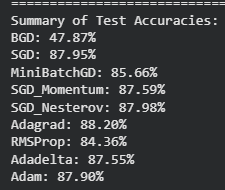

**Conclusions**

**Adagrad - is giving better performance for the fashion mnist dataset.**

Adaptive optimizers (Adam, RMSProp) usually outperform plain SGD on Fashion-MNIST for MLP.

Momentum & Nesterov accelerate convergence, better than vanilla SGD.

Batch size affects BGD/MiniBatchGD performance — full BGD can be slow.

For small networks & simple datasets, differences are visible but moderate.

Observation for regularization (if you add Dropout, L2, noise, etc.) → can further improve accuracy slightly and reduce overfitting.

Choice of optimizer matters: Some optimizers (Adam, Adagrad, SGD with momentum) converge faster and generalize better than plain BGD or vanilla SGD.

Adaptive learning rates are helpful: Adam and Adagrad automatically adjust learning rates, reducing the need for manual tuning.

Practical takeaway: For Fashion-MNIST with a simple MLP:

Adam or Adagrad are the preferred choices.

BGD should be avoided for large datasets.

Use mini-batches and optionally momentum for SGD if you want simplicity and decent performance.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms
import numpy as np
import copy
import random

Data Augmentation

In [ ]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.76MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.5MB/s]


Dropout and Noise Option

Dropout layers included

Can optionally add Gaussian noise to inputs

Parameter sharing/tie is generally done for convolutional layers (we’ll do in CNN later)

In [ ]:
class MLP_Reg(nn.Module):
    def __init__(self, input_size=28*28, hidden1=256, hidden2=128, dropout=0.5, noise_std=0.0):
        super(MLP_Reg, self).__init__()
        self.noise_std = noise_std
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden2, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std  # adding noise to input
        x = self.relu1(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu2(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

**Early Stopping**

Early stopping implemented using patience

Patience here is used for early stopping — it controls how long the model waits before stopping training when it’s not improving. if patience = 3 , it waits until 3 epochs if the model improvement is not seen.

Keeps best model weights



In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=20, patience=3, verbose=False):
    model.train()
    best_loss = float('inf')
    counter = 0
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        if verbose:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_model)
    return model

def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    return acc

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import copy

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# -------------------- MLP MODEL --------------------
class MLP_Reg(nn.Module):
    def __init__(self, input_size=28*28, hidden1=256, hidden2=128, dropout=0.5, noise_std=0.0):
        super(MLP_Reg, self).__init__()
        self.noise_std = noise_std
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden2, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        x = self.relu1(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu2(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# -------------------- TRAIN FUNCTION --------------------
def train_model(model, train_loader, optimizer, criterion, epochs=20, patience=3, verbose=False):
    model.train()
    best_loss = float('inf')
    counter = 0
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        if verbose:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

        # Early stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model)
    return model

# -------------------- TEST FUNCTION --------------------
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# -------------------- EXPERIMENT LOOP --------------------
weight_decays = [0, 0.001, 0.01]
dropout_rates = [0, 0.3, 0.5]
noise_levels  = [0, 0.1]

results = []

for wd in weight_decays:
    for dr in dropout_rates:
        for noise in noise_levels:
            model = MLP_Reg(dropout=dr, noise_std=noise)
            optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)

            model = train_model(model, train_loader, optimizer,
                                nn.CrossEntropyLoss(), epochs=20, patience=5)

            acc = test_model(model, test_loader)

            results.append({
                "L2": wd,
                "Dropout": dr,
                "Noise": noise,
                "Test Accuracy": acc
            })

# Print results
for r in results:
    print(r)

# -------------------- ENSEMBLE --------------------
ensemble_models = []

for i in range(3):
    model = MLP_Reg(dropout=0.5, noise_std=0.1)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

    model = train_model(model, train_loader, optimizer,
                        nn.CrossEntropyLoss(), epochs=20, patience=5)

    ensemble_models.append(model)

def ensemble_test(models, test_loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = sum([torch.softmax(m(images), dim=1) for m in models]) / len(models)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

ensemble_acc = ensemble_test(ensemble_models, test_loader)
print(f"Ensemble Test Accuracy: {ensemble_acc:.2f}%")



100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.39MB/s]


**Ensemble Method**

In [ ]:
ensemble_models = []
for i in range(3):
    model = MLP_Reg(dropout=0.5, noise_std=0.1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
    model = train_model(model, train_loader, optimizer, nn.CrossEntropyLoss(), epochs=20, patience=5, verbose=False)
    ensemble_models.append(model)

# Ensemble prediction
def ensemble_test(models, test_loader):
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = sum([torch.softmax(m(images), dim=1) for m in models]) / len(models)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    return acc

ensemble_acc = ensemble_test(ensemble_models, test_loader)
print(f"Ensemble Test Accuracy: {ensemble_acc:.2f}%")

Conclusions:
Dropout and L2 reduce overfitting

Input noise acts as data augmentation

Ensemble combines predictions → most stable and accurate

Early stopping prevents over-training

**CNN with Parameter Tuning**

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN(dropout=0.5).to(device)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=0.001)
cnn_model = train_model(cnn_model, train_loader, optimizer, nn.CrossEntropyLoss(), epochs=20, patience=5, verbose=True)
cnn_acc = test_model(cnn_model, test_loader)
print(f"CNN Test Accuracy: {cnn_acc:.2f}%")

In [ ]:
# -------------------- CNN MODEL --------------------
class SimpleCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN(dropout=0.5)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=0.001)

cnn_model = train_model(cnn_model, train_loader, optimizer,
                        nn.CrossEntropyLoss(), epochs=20, patience=5, verbose=True)

cnn_acc = test_model(cnn_model, test_loader)
print(f"CNN Test Accuracy: {cnn_acc:.2f}%")